In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import warnings
warnings.filterwarnings('ignore')

from utils import (cara_utility, generate_shared_returns, hold_policy, heuristic_policy)
import backward
import backward_adp
import backward_adp_mc

plt.style.use('seaborn-v0_8-whitegrid')

# ============================================================
# Scenario Configurations
# ============================================================
SCENARIOS = {
    'Base (n=3, T=5)': {
        'n': 3, 'T': 5, 'r': 0.03, 'A': 0.5,
        'a_k': [0.08, 0.06, 0.10],
        's_k': [0.02, 0.015, 0.04],
        'p_init': [0.25, 0.25, 0.25, 0.25],
    },
    'Two Assets (n=2, T=5)': {
        'n': 2, 'T': 5, 'r': 0.03, 'A': 0.7,
        'a_k': [0.09, 0.14],
        's_k': [0.02, 0.04],
        'p_init': [0.50, 0.25, 0.25],
    },
    'Four Assets (n=4, T=5)': {
        'n': 4, 'T': 5, 'r': 0.03, 'A': 0.5,
        'a_k': [0.08, 0.06, 0.10, 0.07],
        's_k': [0.02, 0.015, 0.04, 0.025],
        'p_init': [0.20, 0.20, 0.20, 0.20, 0.20],
    },
    'Four Assets Long (n=4, T=7)': {
        'n': 4, 'T': 7, 'r': 0.02, 'A': 0.7,
        'a_k': [0.06, 0.08, 0.10, 0.13],
        's_k': [0.015, 0.02, 0.025, 0.04],
        'p_init': [0.40, 0.15, 0.15, 0.15, 0.15],
    },
    'Long Horizon (n=3, T=9)': {
        'n': 3, 'T': 9, 'r': 0.03, 'A': 0.5,
        'a_k': [0.08, 0.06, 0.10],
        's_k': [0.02, 0.015, 0.04],
        'p_init': [0.25, 0.25, 0.25, 0.25],
    },
    'High Risk Aversion (A=3.0)': {
        'n': 3, 'T': 5, 'r': 0.03, 'A': 3.0,
        'a_k': [0.08, 0.10, 0.12],
        's_k': [0.02, 0.025, 0.03],
        'p_init': [0.50, 0.20, 0.15, 0.15],
    },
    'Low Risk Aversion (A=0.1)': {
        'n': 3, 'T': 5, 'r': 0.03, 'A': 0.1,
        'a_k': [0.08, 0.10, 0.12],
        's_k': [0.02, 0.025, 0.03],
        'p_init': [0.50, 0.20, 0.15, 0.15],
    },
}

NUM_EVAL = 2000
SEED = 42

print(f"Defined {len(SCENARIOS)} scenarios:")
for name, cfg in SCENARIOS.items():
    print(f"  {name}: n={cfg['n']}, T={cfg['T']}, r={cfg['r']}, A={cfg['A']}")

Defined 7 scenarios:
  Base (n=3, T=5): n=3, T=5, r=0.03, A=0.5
  Two Assets (n=2, T=5): n=2, T=5, r=0.03, A=0.7
  Four Assets (n=4, T=5): n=4, T=5, r=0.03, A=0.5
  Four Assets Long (n=4, T=7): n=4, T=7, r=0.02, A=0.7
  Long Horizon (n=3, T=9): n=3, T=9, r=0.03, A=0.5
  High Risk Aversion (A=3.0): n=3, T=5, r=0.03, A=3.0
  Low Risk Aversion (A=0.1): n=3, T=5, r=0.03, A=0.1


In [2]:
# ============================================================
# Helper: simulate a baseline policy with shared returns
# ============================================================
def simulate_baseline(cfg, get_action, shared_returns, num_episodes=NUM_EVAL):
    """Simulate a baseline policy (hold or heuristic) with shared returns.
    get_action(t, W, p_risky) -> action array of shape (n,)
    Enforces turnover and leverage constraints.
    """
    n, T, r, A = cfg['n'], cfg['T'], cfg['r'], cfg['A']
    a_k = np.array(cfg['a_k'])
    std_k = np.sqrt(np.array(cfg['s_k']))
    p_init = np.array(cfg['p_init'])
    max_turnover = 0.10
    leverage_factor = 2.0

    wealth_paths = np.zeros((num_episodes, T + 1))
    alloc_history = np.zeros((num_episodes, T, n + 1))
    terminal_wealths = np.zeros(num_episodes)

    for ep in range(num_episodes):
        W = 1.0
        p = p_init.copy()
        wealth_paths[ep, 0] = W

        for t in range(T):
            p_risky = p[1:].copy()
            action = get_action(t, W, p_risky)

            # Enforce turnover constraint
            d_cash = -action.sum()
            turnover = 0.5 * (np.abs(d_cash) + np.abs(action).sum())
            if turnover > max_turnover + 1e-10:
                action = action * (max_turnover / turnover)

            new_pr = p_risky + action
            new_cash = 1.0 - new_pr.sum()

            # Enforce leverage constraint
            gross = np.abs(new_cash) + np.abs(new_pr).sum()
            if gross > leverage_factor + 1e-10:
                scale = leverage_factor / gross
                new_pr = p_risky + action * scale
                new_cash = 1.0 - new_pr.sum()

            alloc_history[ep, t] = np.concatenate([[new_cash], new_pr])

            R = shared_returns[ep, t]
            port_ret = new_cash * r + (new_pr * R).sum()
            W_new = W * (1.0 + port_ret)

            if W_new <= 0.001:
                W = 0.001
                p = np.concatenate([[1.0], np.zeros(n)])
            else:
                denom = 1.0 + port_ret
                p = np.concatenate([[new_cash * (1 + r) / denom],
                                     new_pr * (1 + R) / denom])
                W = W_new
            wealth_paths[ep, t + 1] = W

        terminal_wealths[ep] = W

    utils = cara_utility(terminal_wealths, A)
    return {
        'avg_utility': float(np.mean(utils)),
        'std_err': float(np.std(utils) / np.sqrt(num_episodes)),
        'avg_wealth': float(np.mean(terminal_wealths)),
        'med_wealth': float(np.median(terminal_wealths)),
        'wealth_paths': wealth_paths,
        'terminal_wealths': terminal_wealths,
        'alloc_history': alloc_history,
    }


def print_table(label, results, n):
    """Print utility/wealth table and average final allocation for each method."""
    print(f"\n{'='*75}")
    print(f"  {label}")
    print(f"{'='*75}")
    print(f"  {'Method':<16} {'Avg Utility':>12} {'+/- SE':>10} {'Avg Wealth':>12} {'Med Wealth':>12}")
    print(f"  {'-'*62}")
    for name, res in results.items():
        print(f"  {name:<16} {res['avg_utility']:>12.5f} {res['std_err']:>10.5f} "
              f"{res['avg_wealth']:>12.4f} {res['med_wealth']:>12.4f}")

    # Print average final-period allocation
    asset_names = ['Cash'] + [f'A{k+1}' for k in range(n)]
    header = f"  {'Method':<16}"
    for aname in asset_names:
        header += f" {aname:>8}"
    print(f"\n  Average Final Allocation (last rebalance):")
    print(header)
    print(f"  {'-'*( 16 + 9 * (n + 1) )}")
    for name, res in results.items():
        alloc = res.get('alloc_history')
        if alloc is not None and len(alloc.shape) == 3:
            final_alloc = alloc[:, -1, :].mean(axis=0)  # avg over episodes
            row = f"  {name:<16}"
            for val in final_alloc:
                row += f" {val:>8.3f}"
            print(row)
        else:
            print(f"  {name:<16}  (no allocation data)")


print("Helper functions defined.")

Helper functions defined.


## Run All Methods

For each scenario we:
1. Generate **shared returns** so every method faces the same market paths (fair comparison)
2. Run all 5 methods: Hold, Heuristic, Tabular DP, ADP-Hermite, ADP-MC
3. Evaluate using the shared returns

In [3]:
# ============================================================
# Load saved results (skip this cell if you want to re-run)
# ============================================================
import pickle, os

if os.path.exists('all_results.pkl'):
    with open('all_results.pkl', 'rb') as f:
        saved = pickle.load(f)
    all_results = saved['results']
    shared_returns = saved['shared_returns']
    print(f"Loaded {len(all_results)} scenarios from all_results.pkl:")
    for name in all_results:
        print(f"  {name}: {list(all_results[name].keys())}")
    print(f"\nShared returns loaded for {len(shared_returns)} scenarios.")
    print("Skip the run cells below and go straight to plots!")
else:
    print("No saved results found. Run the cells below to generate results.")

Loaded 7 scenarios from all_results.pkl:
  Base (n=3, T=5): ['Hold', 'Heuristic', 'Tabular DP', 'ADP-Hermite', 'ADP-MC', 'PPO', 'A2C']
  Two Assets (n=2, T=5): ['Hold', 'Heuristic', 'Tabular DP', 'ADP-Hermite', 'ADP-MC', 'PPO', 'A2C']
  Four Assets (n=4, T=5): ['Hold', 'Heuristic', 'Tabular DP', 'ADP-Hermite', 'ADP-MC', 'PPO', 'A2C']
  Four Assets Long (n=4, T=7): ['Hold', 'Heuristic', 'Tabular DP', 'ADP-Hermite', 'ADP-MC', 'PPO', 'A2C']
  Long Horizon (n=3, T=9): ['Hold', 'Heuristic', 'Tabular DP', 'ADP-Hermite', 'ADP-MC', 'PPO', 'A2C']
  High Risk Aversion (A=3.0): ['Hold', 'Heuristic', 'Tabular DP', 'ADP-Hermite', 'ADP-MC', 'PPO', 'A2C']
  Low Risk Aversion (A=0.1): ['Hold', 'Heuristic', 'Tabular DP', 'ADP-Hermite', 'ADP-MC', 'PPO', 'A2C']

Shared returns loaded for 7 scenarios.
Skip the run cells below and go straight to plots!


In [4]:
def run_all_methods(cfg, label, adp_n_train=3000, adp_epochs=150):
    """Run all 5 methods on a scenario and return results dict."""
    n, T, r, A = cfg['n'], cfg['T'], cfg['r'], cfg['A']
    p_init = cfg['p_init']
    results = {}

    # Generate shared returns for fair comparison
    shared = generate_shared_returns(NUM_EVAL, T, n, cfg['a_k'], cfg['s_k'], seed=SEED)

    print(f"\n{'#'*75}")
    print(f"  Scenario: {label}")
    print(f"  n={n}, T={T}, r={r}, A={A}, p_init={p_init}")
    print(f"{'#'*75}")

    # --- 1. Hold baseline ---
    print("\n[Hold] ...")
    results['Hold'] = simulate_baseline(
        cfg, lambda t, W, p: hold_policy(n), shared)
    print(f"  utility={results['Hold']['avg_utility']:.5f}")

    # --- 2. Heuristic baseline ---
    print("[Heuristic] ...")
    h_action = heuristic_policy(cfg['a_k'], cfg['s_k'], r)
    results['Heuristic'] = simulate_baseline(
        cfg, lambda t, W, p: h_action, shared)
    print(f"  utility={results['Heuristic']['avg_utility']:.5f}")

    # --- 3. Tabular DP ---
    # Grid resolution: finer for small n (curse of dimensionality limits n=4)
    # prop range [-0.2, 1.0] allows mild leverage (negative cash) like other methods
    if n <= 2:
        dp_prop_step = 0.10
    elif n <= 3:
        dp_prop_step = 0.20
    else:
        dp_prop_step = 0.50

    print(f"[Tabular DP] (prop_step={dp_prop_step}) ...")
    t0 = time.time()
    v_grids, policy, dp_cfg = backward.solve_dp(
        n=n, T=T, r=r, A=A,
        a_k=list(cfg['a_k']), s_k=list(cfg['s_k']),
        prop_min=-0.20, prop_max=1.0,
        prop_step=dp_prop_step,
        leverage_factor=2.0, p_init=p_init,
    )
    dp_res = backward.simulate_dp(v_grids, policy, dp_cfg,
                                   p_init=p_init, num_episodes=NUM_EVAL,
                                   verbose=False, returns=shared)
    utils_dp = cara_utility(dp_res['terminal_wealths'], A)
    results['Tabular DP'] = {
        'avg_utility': float(np.mean(utils_dp)),
        'std_err': float(np.std(utils_dp) / np.sqrt(NUM_EVAL)),
        'avg_wealth': float(np.mean(dp_res['terminal_wealths'])),
        'med_wealth': float(np.median(dp_res['terminal_wealths'])),
        'wealth_paths': dp_res['wealth_paths'],
        'terminal_wealths': dp_res['terminal_wealths'],
        'alloc_history': dp_res.get('alloc_history', None),
    }
    print(f"  utility={results['Tabular DP']['avg_utility']:.5f} ({time.time()-t0:.1f}s)")

    # --- 4. ADP-Hermite ---
    print("[ADP-Hermite] ...")
    t0 = time.time()
    v_nets, pol_nets, adp_cfg = backward_adp.solve_dp(
        n=n, T=T, r=r, A=A,
        a_k=list(cfg['a_k']), s_k=list(cfg['s_k']),
        leverage_factor=2.0, p_init=p_init,
        hidden_size=128, n_train=adp_n_train, epochs=adp_epochs, lr=1e-3,
    )
    adp_res = backward_adp.simulate_dp(v_nets, pol_nets, adp_cfg,
                                        p_init=p_init, num_episodes=NUM_EVAL,
                                        verbose=False, returns=shared)
    results['ADP-Hermite'] = {
        'avg_utility': adp_res['avg_utility'],
        'std_err': adp_res['std_err'],
        'avg_wealth': adp_res['avg_wealth'],
        'med_wealth': adp_res['med_wealth'],
        'wealth_paths': adp_res['wealth_paths'],
        'terminal_wealths': adp_res['terminal_wealths'],
        'alloc_history': adp_res['alloc_history'],
    }
    print(f"  utility={results['ADP-Hermite']['avg_utility']:.5f} ({time.time()-t0:.1f}s)")

    # --- 5. ADP-MC ---
    print("[ADP-MC] ...")
    t0 = time.time()
    v_nets_mc, pol_nets_mc, mc_cfg = backward_adp_mc.solve_dp(
        n=n, T=T, r=r, A=A,
        a_k=list(cfg['a_k']), s_k=list(cfg['s_k']),
        leverage_factor=2.0, p_init=p_init,
        hidden_size=128, n_train=adp_n_train, epochs=adp_epochs, lr=1e-3,
        n_mc=200,
    )
    mc_res = backward_adp_mc.simulate_dp(v_nets_mc, pol_nets_mc, mc_cfg,
                                          p_init=p_init, num_episodes=NUM_EVAL,
                                          verbose=False, returns=shared)
    results['ADP-MC'] = {
        'avg_utility': mc_res['avg_utility'],
        'std_err': mc_res['std_err'],
        'avg_wealth': mc_res['avg_wealth'],
        'med_wealth': mc_res['med_wealth'],
        'wealth_paths': mc_res['wealth_paths'],
        'terminal_wealths': mc_res['terminal_wealths'],
        'alloc_history': mc_res['alloc_history'],
    }
    print(f"  utility={results['ADP-MC']['avg_utility']:.5f} ({time.time()-t0:.1f}s)")

    print_table(label, results, n)
    return results

print("run_all_methods() defined.")

run_all_methods() defined.


In [5]:
# ============================================================
# Run the base scenario first as a demo
# ============================================================
all_results = {}

label = 'Base (n=3, T=5)'
cfg = SCENARIOS[label]
all_results[label] = run_all_methods(cfg, label)


###########################################################################
  Scenario: Base (n=3, T=5)
  n=3, T=5, r=0.03, A=0.5, p_init=[0.25, 0.25, 0.25, 0.25]
###########################################################################

[Hold] ...
  utility=0.99923
[Heuristic] ...
  utility=1.04225
[Tabular DP] (prop_step=0.2) ...
Setup: n=3, T=5, r=0.03, A=0.5
  Mean returns:   [np.float64(0.08), np.float64(0.06), np.float64(0.1)]
  Excess returns: [np.float64(0.05), np.float64(0.03), np.float64(0.07)]
  Wealth grid: 15 pts in [0.05, 3.5]
  Prop grid: 7 pts in [-0.2, 1.0], step=0.2
  Prop combos: 343
  Actions: 309 feasible
  Quadrature: 5^3 = 125 points

Backward Induction
  t=4: 3,795 states, 29.0s
  t=3: 3,795 states, 30.5s
  t=2: 3,795 states, 33.9s
  t=1: 3,795 states, 33.3s
  t=0: 3,795 states, 33.1s

Total solve time: 159.7s
  utility=1.04983 (162.1s)
[ADP-Hermite] ...
ADP Setup: n=3, T=5, r=0.03, A=0.5
  Mean returns:   [np.float64(0.08), np.float64(0.06), np.float64(0.1)]

In [6]:
# ============================================================
# Run remaining scenarios
# ============================================================
for label, cfg in SCENARIOS.items():
    if label in all_results:
        continue
    all_results[label] = run_all_methods(cfg, label)


###########################################################################
  Scenario: Two Assets (n=2, T=5)
  n=2, T=5, r=0.03, A=0.7, p_init=[0.5, 0.25, 0.25]
###########################################################################

[Hold] ...
  utility=0.90451
[Heuristic] ...
  utility=0.95804
[Tabular DP] (prop_step=0.1) ...
Setup: n=2, T=5, r=0.03, A=0.7
  Mean returns:   [np.float64(0.09), np.float64(0.14)]
  Excess returns: [np.float64(0.06), np.float64(0.11)]
  Wealth grid: 15 pts in [0.05, 3.5]
  Prop grid: 13 pts in [-0.2, 1.0], step=0.1
  Prop combos: 169
  Actions: 61 feasible
  Quadrature: 5^2 = 25 points

Backward Induction
  t=4: 2,385 states, 0.7s
  t=3: 2,385 states, 0.7s
  t=2: 2,385 states, 0.7s
  t=1: 2,385 states, 0.7s
  t=0: 2,385 states, 0.7s

Total solve time: 3.4s
  utility=0.96849 (4.4s)
[ADP-Hermite] ...
ADP Setup: n=2, T=5, r=0.03, A=0.7
  Mean returns:   [np.float64(0.09), np.float64(0.14)]
  Excess returns: [np.float64(0.06), np.float64(0.11)]
  Train

In [7]:
# ============================================================
# Save results + shared returns to disk
# ============================================================
import pickle

save_data = {}
for scenario_name, results in all_results.items():
    save_data[scenario_name] = {}
    for method_name, res in results.items():
        save_data[scenario_name][method_name] = {
            'avg_utility': res['avg_utility'],
            'std_err': res['std_err'],
            'avg_wealth': res['avg_wealth'],
            'med_wealth': res['med_wealth'],
            'wealth_paths': res['wealth_paths'],
            'terminal_wealths': res['terminal_wealths'],
            'alloc_history': res['alloc_history'],
        }

# Also save the shared returns for each scenario (for reproducibility)
shared_returns = {}
for name, cfg in SCENARIOS.items():
    shared_returns[name] = generate_shared_returns(
        NUM_EVAL, cfg['T'], cfg['n'], cfg['a_k'], cfg['s_k'], seed=SEED)

with open('dp_results.pkl', 'wb') as f:
    pickle.dump({'results': save_data, 'shared_returns': shared_returns,
                 'SCENARIOS': SCENARIOS, 'NUM_EVAL': NUM_EVAL, 'SEED': SEED}, f)

print(f"Saved {len(save_data)} scenarios + shared returns to dp_results.pkl")

Saved 7 scenarios + shared returns to dp_results.pkl


## Visualizations

In [8]:
colors = {
    'Hold': 'gray', 'Heuristic': 'brown',
    'Tabular DP': 'tab:blue', 'ADP-Hermite': 'tab:green',
    'ADP-MC': 'tab:cyan',
}
linestyles = {
    'Hold': ':', 'Heuristic': ':',
    'Tabular DP': '-', 'ADP-Hermite': '-',
    'ADP-MC': '-',
}
markers = {
    'Hold': 'x', 'Heuristic': '+',
    'Tabular DP': 's', 'ADP-Hermite': 'o',
    'ADP-MC': '^',
}

### Utility Over Time

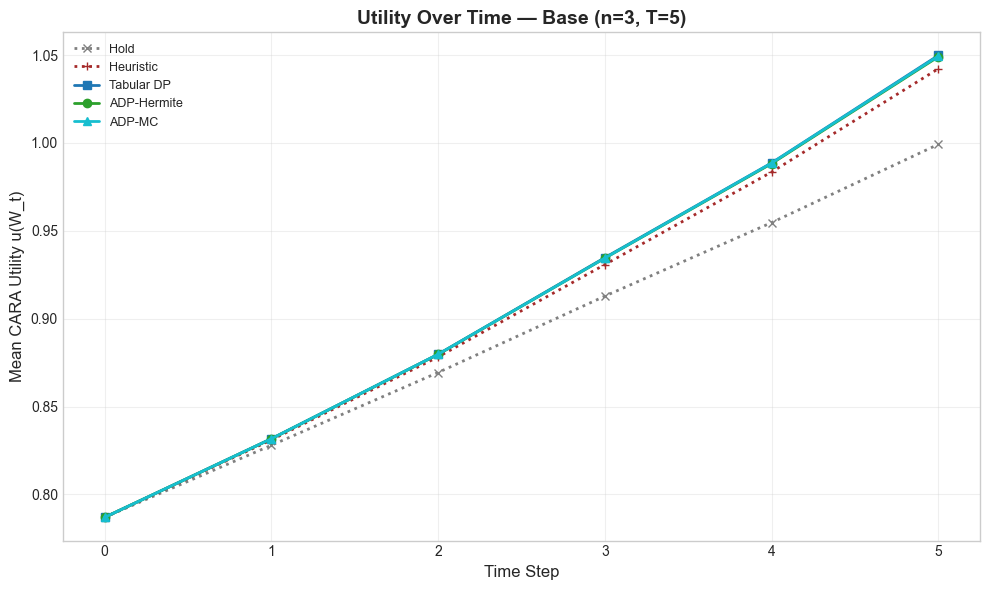

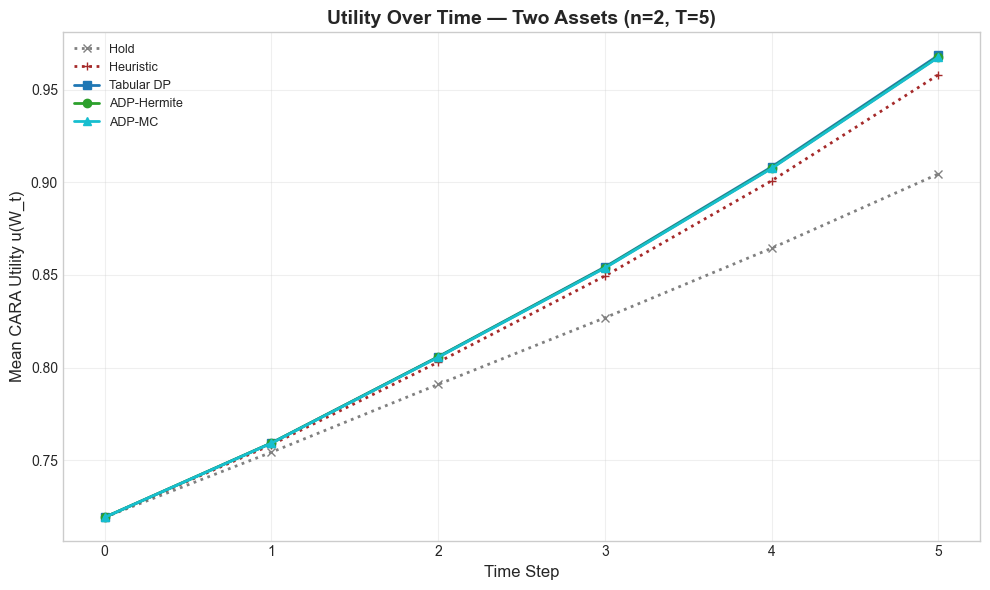

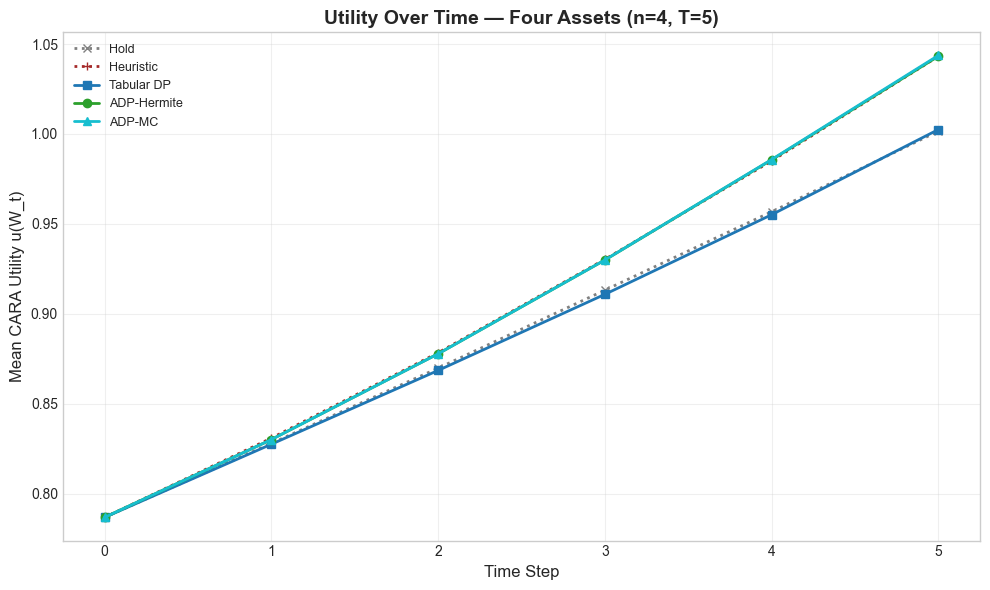

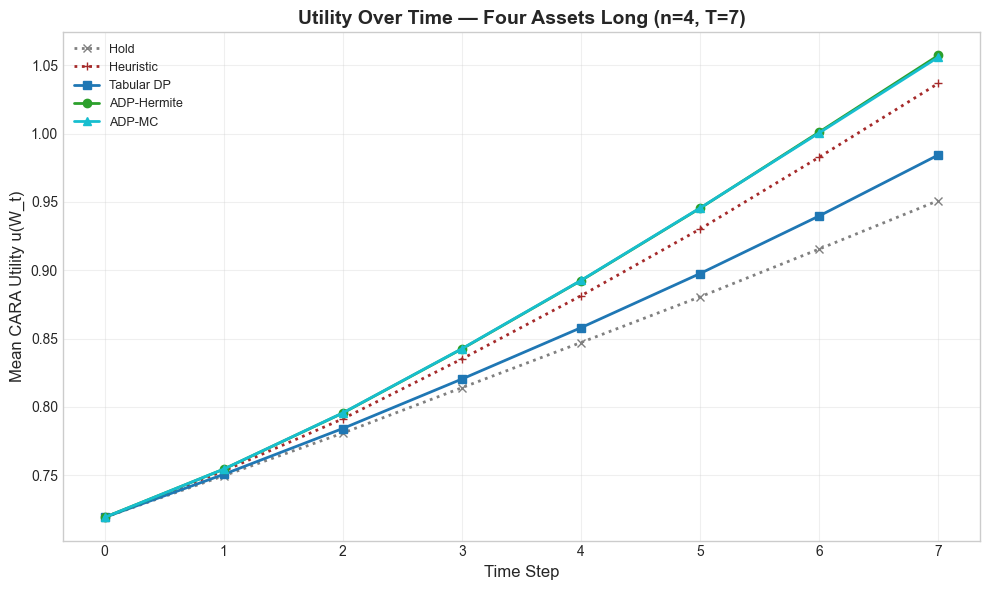

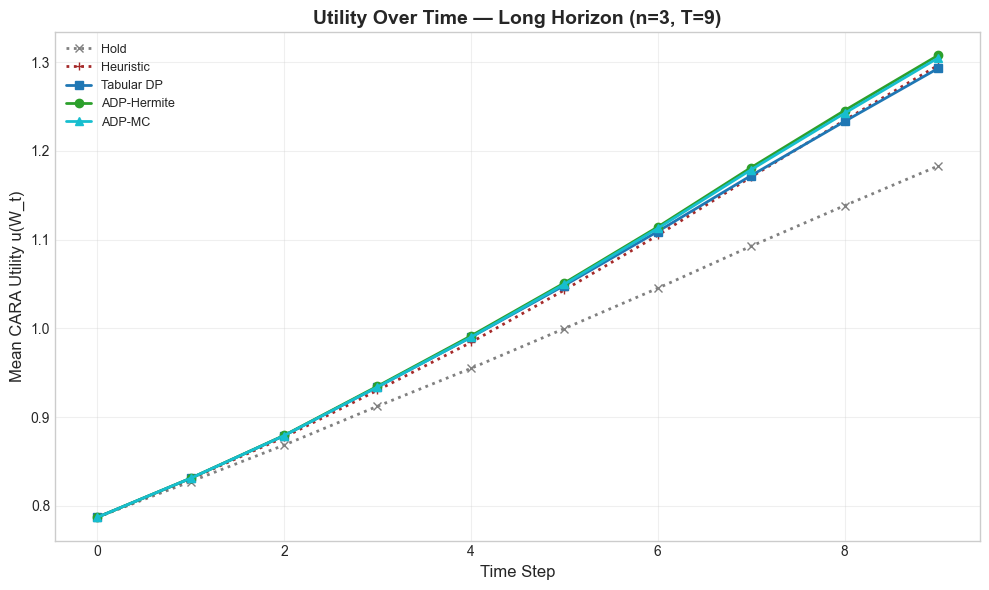

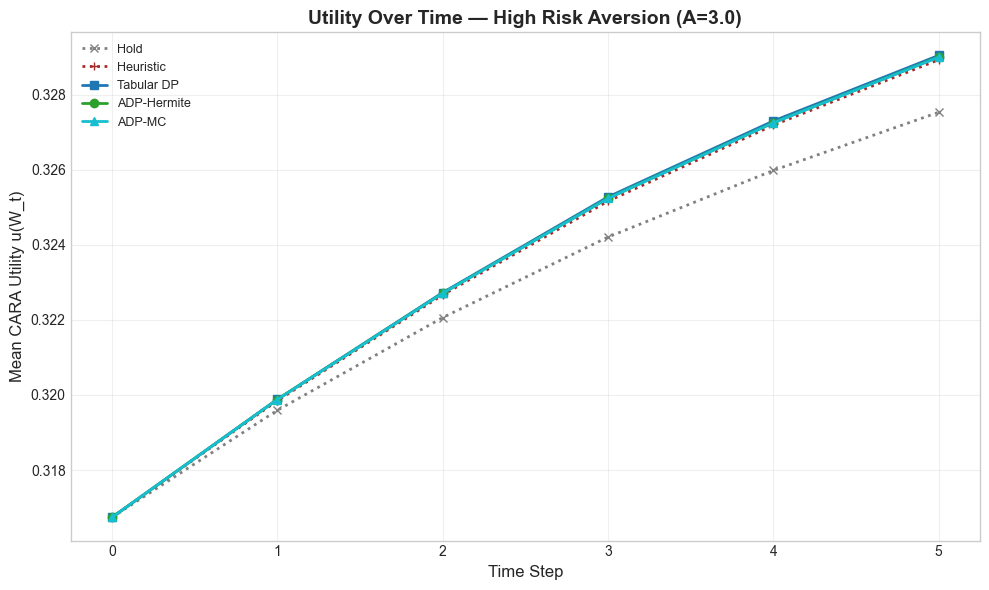

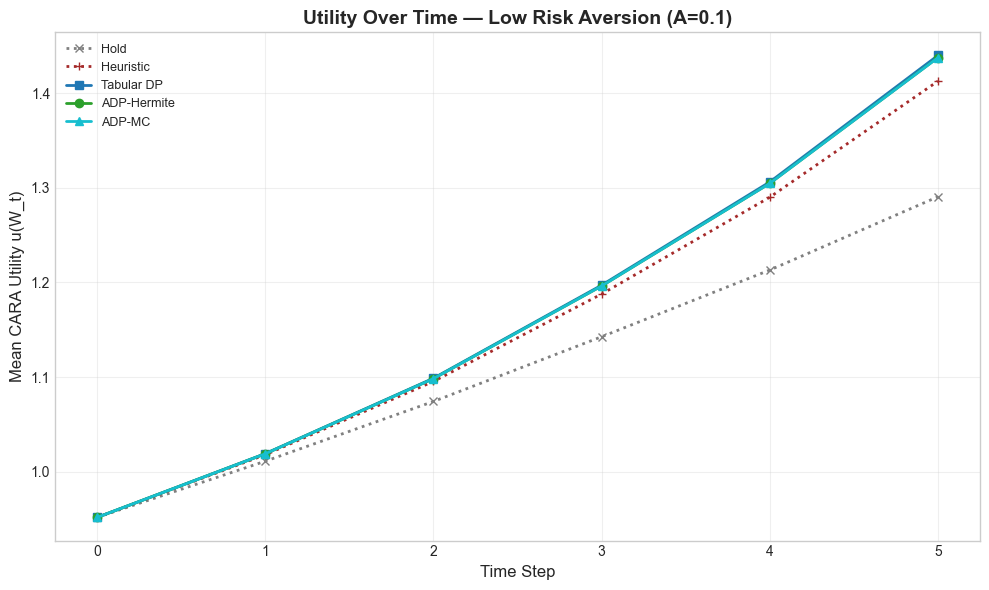

In [9]:
for scenario_name, results in all_results.items():
    cfg = SCENARIOS[scenario_name]
    A = cfg['A']
    T = cfg['T']
    ts = np.arange(T + 1)

    fig, ax = plt.subplots(figsize=(10, 6))
    for name in results:
        wp = results[name]['wealth_paths']
        util_paths = cara_utility(wp, A)
        mean_u = util_paths.mean(axis=0)
        c = colors.get(name, 'black')
        ls = linestyles.get(name, '-')
        mk = markers.get(name, None)
        ax.plot(ts, mean_u, label=name, color=c, linestyle=ls,
                marker=mk, markersize=6, linewidth=2)
    ax.set_xlabel('Time Step', fontsize=12)
    ax.set_ylabel('Mean CARA Utility u(W_t)', fontsize=12)
    ax.set_title(f'Utility Over Time — {scenario_name}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Wealth Over Time

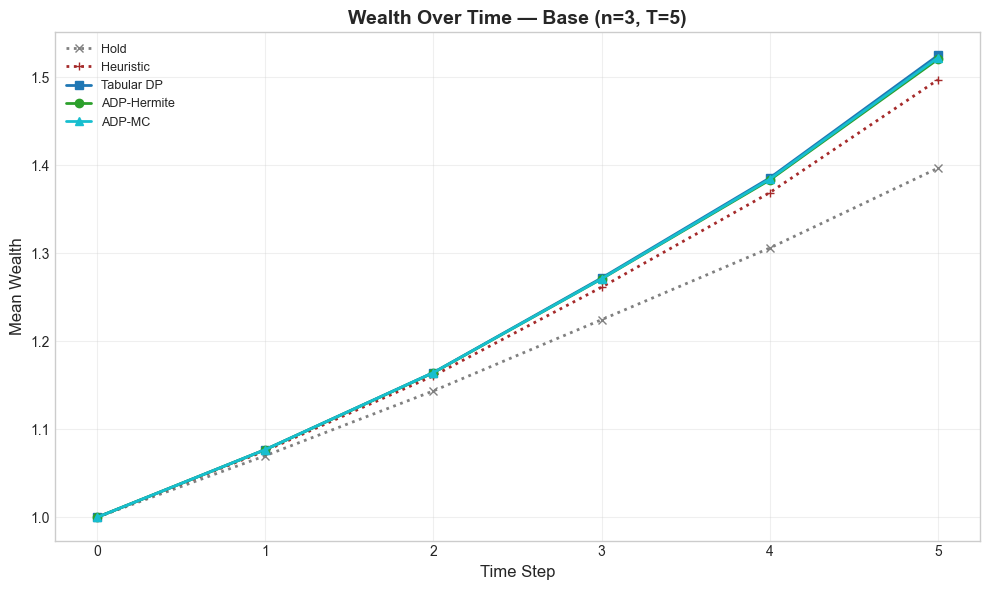

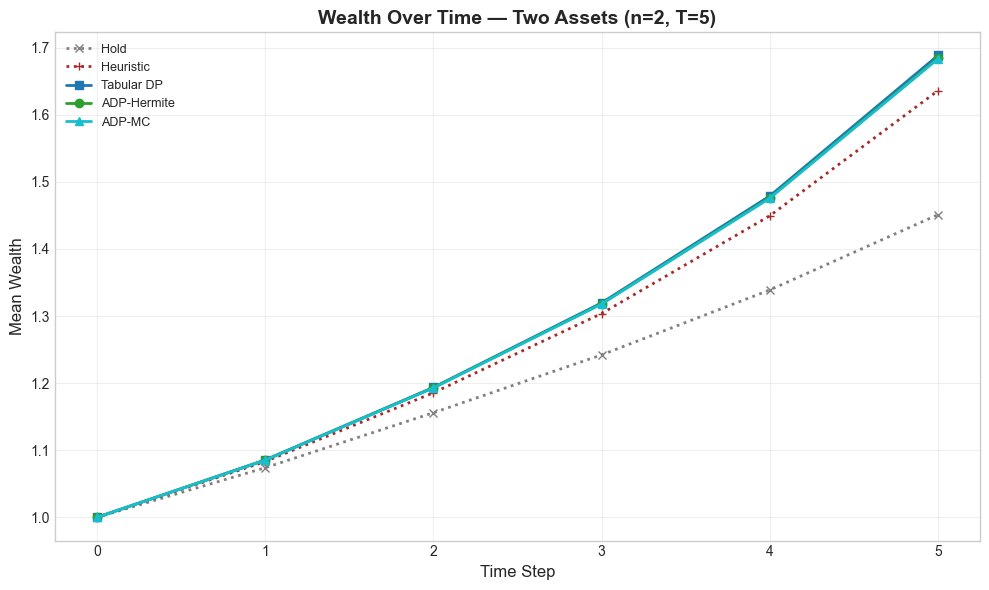

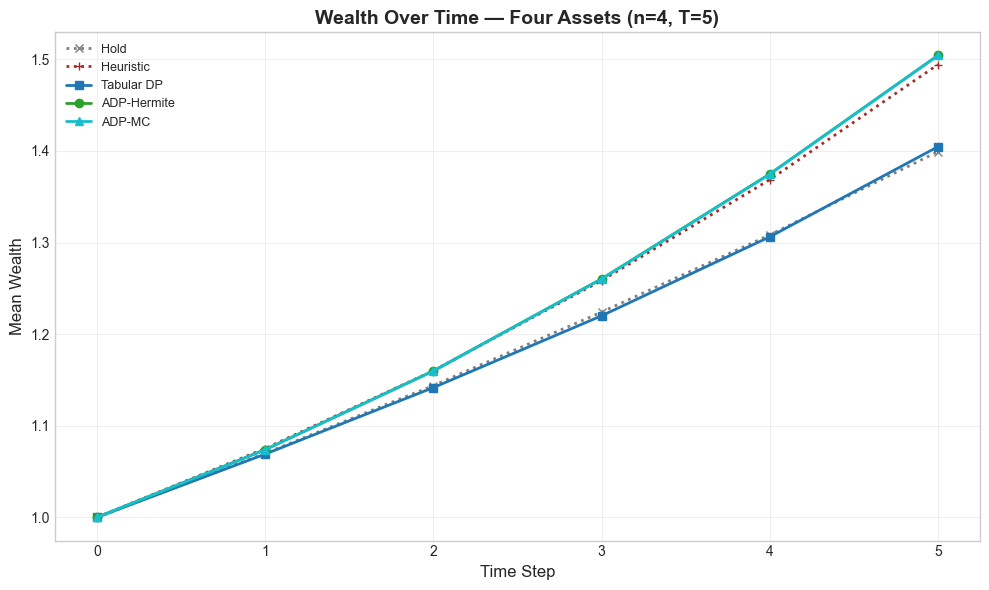

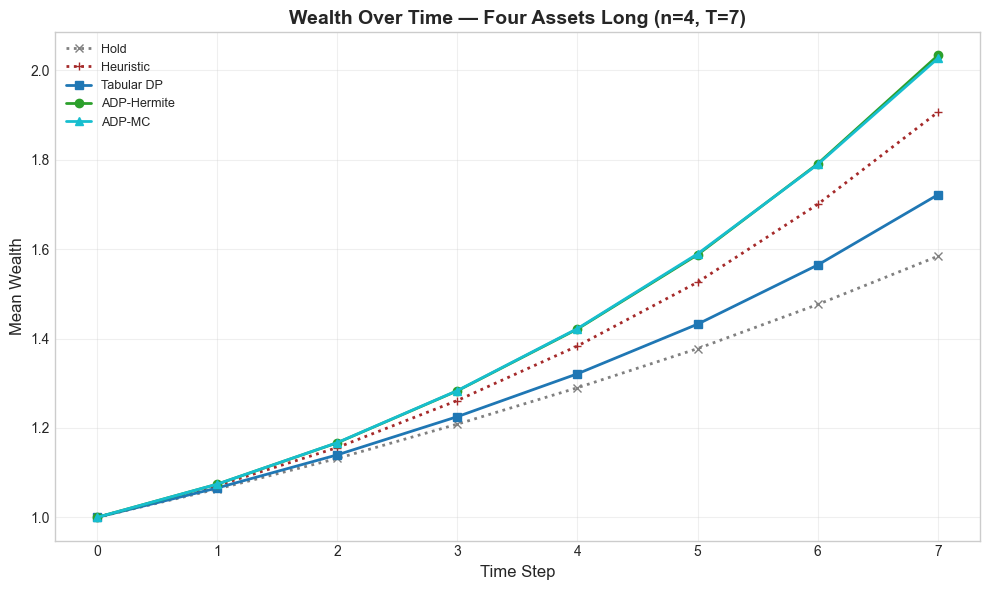

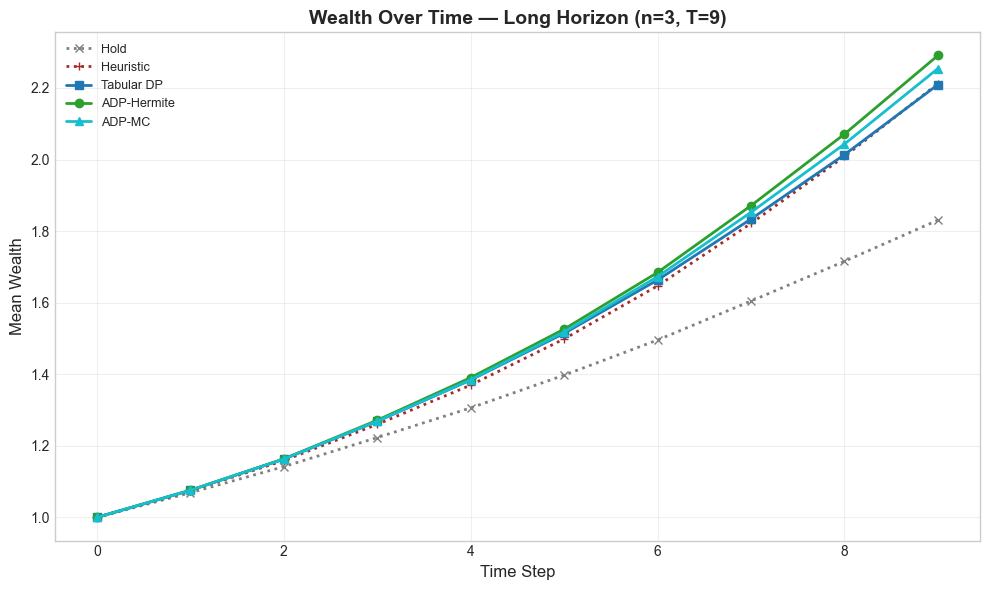

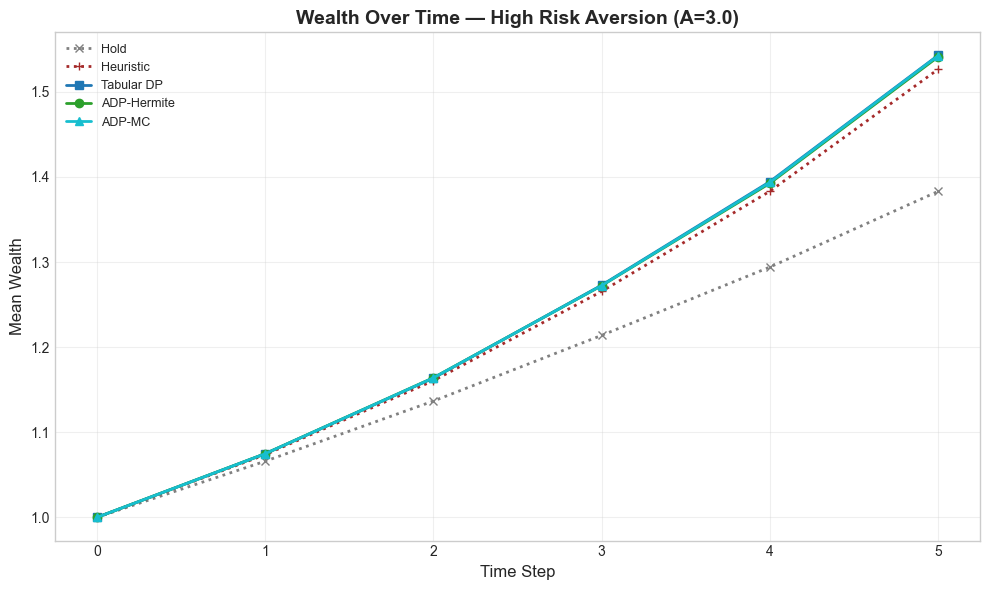

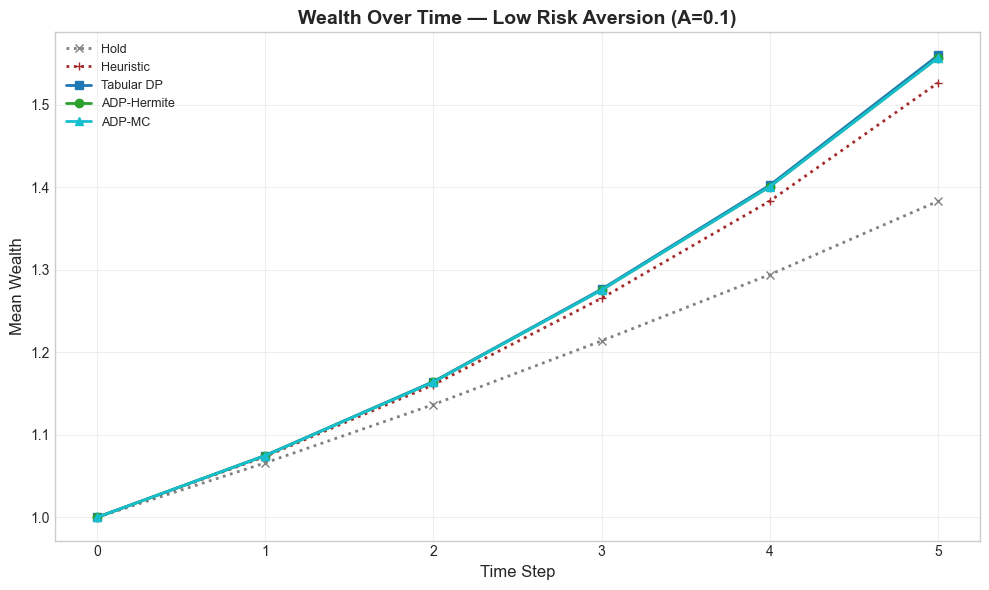

In [10]:
for scenario_name, results in all_results.items():
    cfg = SCENARIOS[scenario_name]
    T = cfg['T']
    ts = np.arange(T + 1)

    fig, ax = plt.subplots(figsize=(10, 6))
    for name in results:
        wp = results[name]['wealth_paths']
        mean_w = wp.mean(axis=0)
        c = colors.get(name, 'black')
        ls = linestyles.get(name, '-')
        mk = markers.get(name, None)
        ax.plot(ts, mean_w, label=name, color=c, linestyle=ls,
                marker=mk, markersize=6, linewidth=2)
    ax.set_xlabel('Time Step', fontsize=12)
    ax.set_ylabel('Mean Wealth', fontsize=12)
    ax.set_title(f'Wealth Over Time — {scenario_name}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Allocation Trends

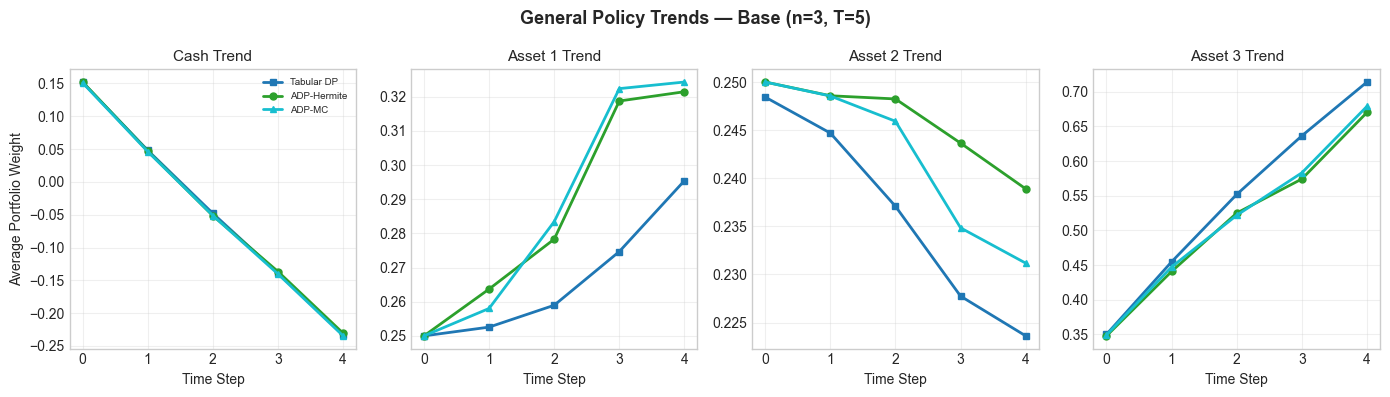

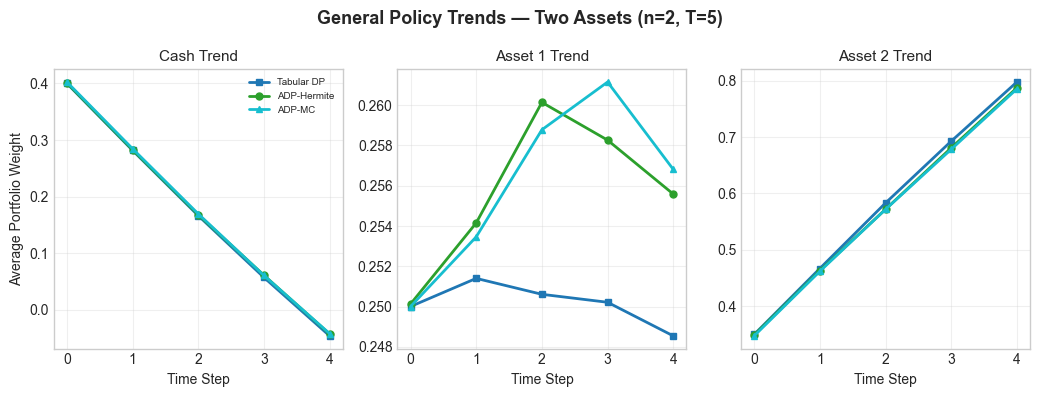

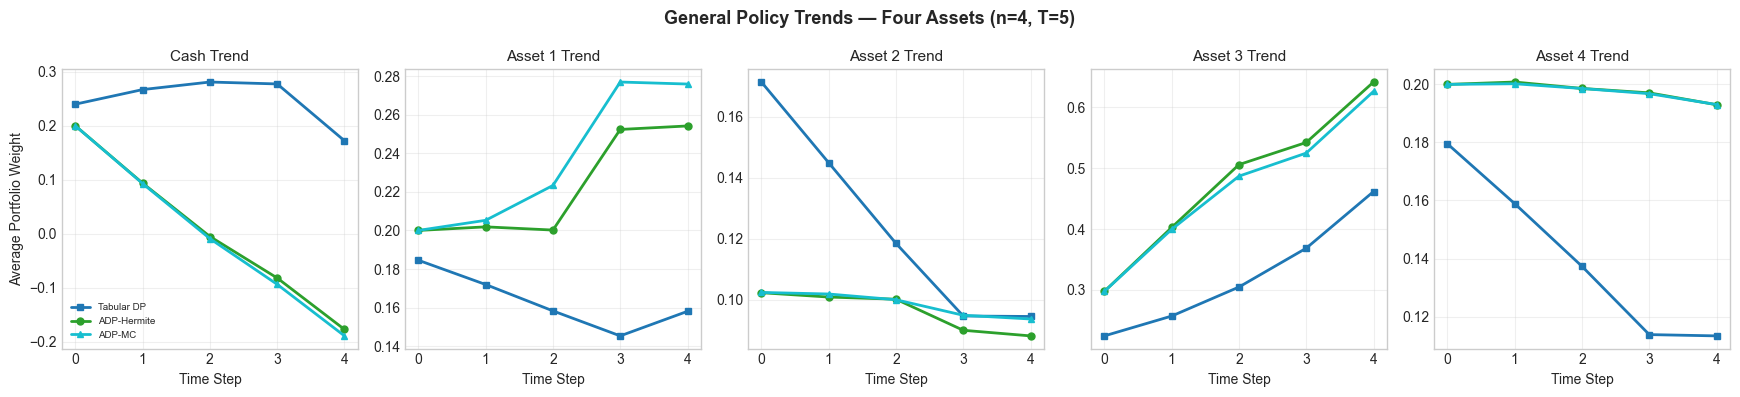

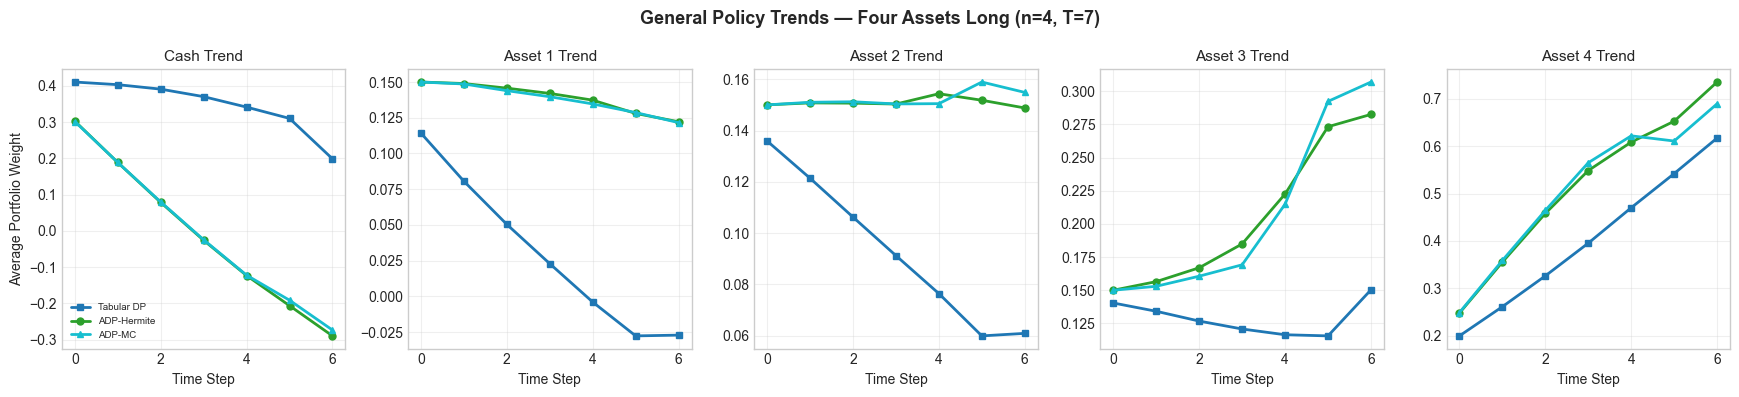

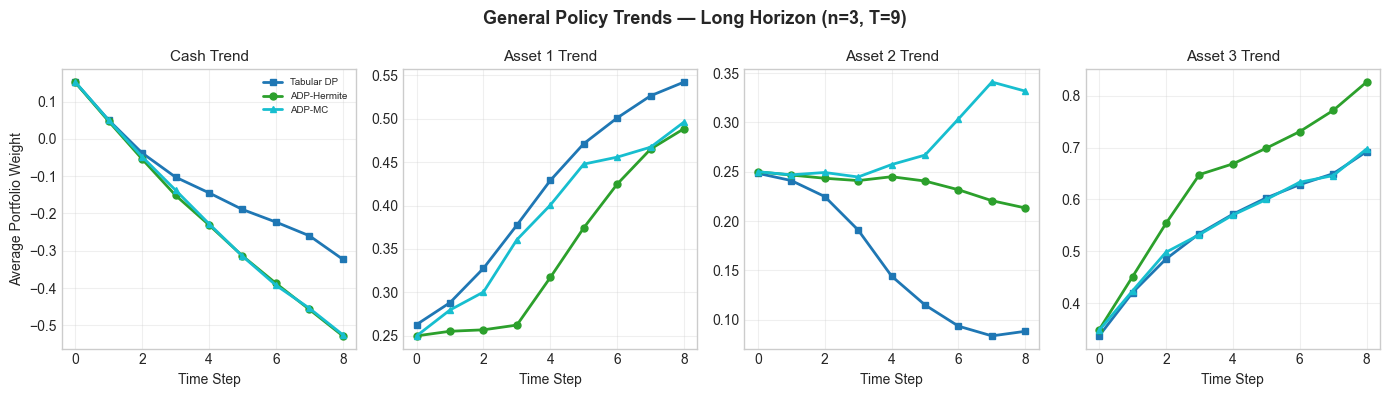

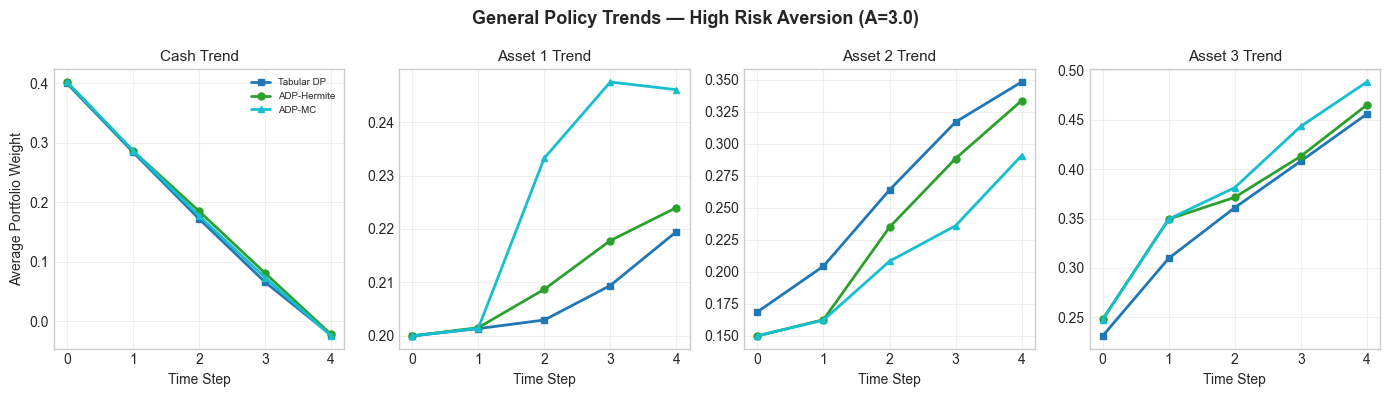

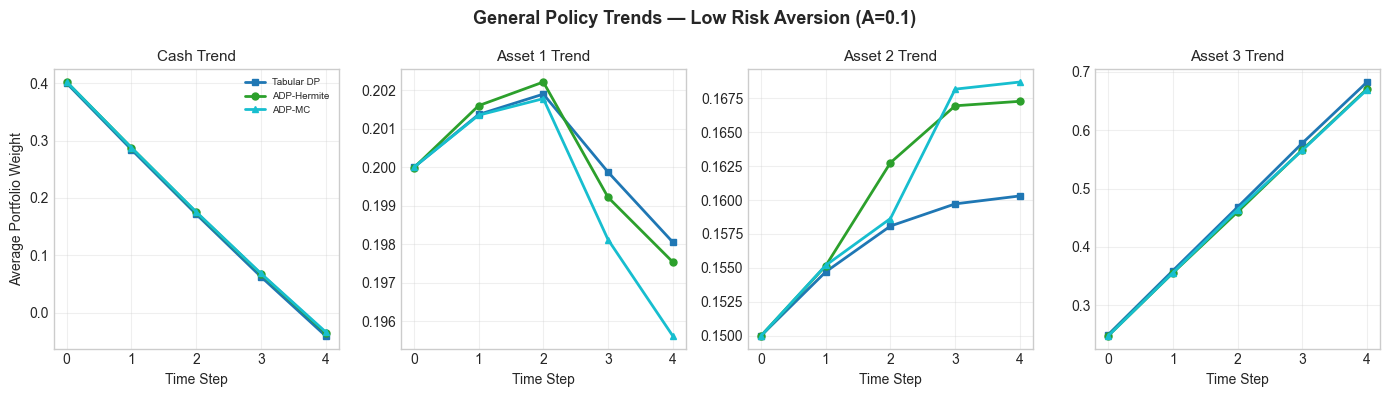

In [11]:
opt_methods = [m for m in all_results[list(all_results.keys())[0]]
              if m not in ('Hold', 'Heuristic')]

for scenario_name, results in all_results.items():
    cfg = SCENARIOS[scenario_name]
    n = cfg['n']
    T = cfg['T']
    asset_names = ['Cash'] + [f'Asset {k}' for k in range(1, n + 1)]

    fig, axes = plt.subplots(1, n + 1, figsize=((n + 1) * 3.5, 4))
    if n + 1 == 1:
        axes = [axes]
    time_steps = np.arange(T)

    for asset_idx in range(n + 1):
        ax = axes[asset_idx]
        for method in opt_methods:
            if method not in results:
                continue
            alloc = results[method].get('alloc_history')
            if alloc is None or len(alloc.shape) != 3:
                continue
            mean_trend = alloc[:, :, asset_idx].mean(axis=0)
            c = colors.get(method, 'black')
            ls = linestyles.get(method, '-')
            mk = markers.get(method, 'o')
            ax.plot(time_steps, mean_trend, marker=mk, linestyle=ls,
                    label=method, color=c, linewidth=2, markersize=5)
        ax.set_title(f'{asset_names[asset_idx]} Trend', fontsize=11)
        ax.set_xlabel('Time Step')
        ax.grid(True, alpha=0.3)
        if asset_idx == 0:
            ax.set_ylabel('Average Portfolio Weight')
            ax.legend(loc='best', fontsize=7)

    fig.suptitle(f'General Policy Trends — {scenario_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Summary Table

In [12]:
for scenario_name, results in all_results.items():
    n = SCENARIOS[scenario_name]['n']
    print(f"\n{'='*80}")
    print(f"  {scenario_name}")
    print(f"{'='*80}")
    print(f"  {'Method':<16} {'Avg Utility':>12} {'+/- SE':>10} {'Avg Wealth':>12} {'Med Wealth':>12}")
    print(f"  {'-'*62}")
    for name, res in results.items():
        print(f"  {name:<16} {res['avg_utility']:>12.5f} {res['std_err']:>10.5f} "
              f"{res['avg_wealth']:>12.4f} {res['med_wealth']:>12.4f}")


  Base (n=3, T=5)
  Method            Avg Utility     +/- SE   Avg Wealth   Med Wealth
  --------------------------------------------------------------
  Hold                  0.99923    0.00239       1.3966       1.3783
  Heuristic             1.04225    0.00326       1.4970       1.4633
  Tabular DP            1.04983    0.00390       1.5246       1.4727
  ADP-Hermite           1.04907    0.00375       1.5203       1.4738
  ADP-MC                1.04947    0.00379       1.5222       1.4728

  Two Assets (n=2, T=5)
  Method            Avg Utility     +/- SE   Avg Wealth   Med Wealth
  --------------------------------------------------------------
  Hold                  0.90451    0.00181       1.4509       1.4172
  Heuristic             0.95804    0.00263       1.6357       1.5837
  Tabular DP            0.96849    0.00302       1.6882       1.6149
  ADP-Hermite           0.96772    0.00299       1.6844       1.6137
  ADP-MC                0.96748    0.00298       1.6832       1.615

## Observations

### Utility and Wealth Convergence

Across all 7 scenarios, the three DP methods (Tabular DP, ADP-Hermite, ADP-MC) produce **overlapping utility and wealth trajectories**, all significantly outperforming the Hold and Heuristic baselines. This confirms that all three methods find the same optimal expected outcome.

### Allocation Convergence

The allocation trend plots provide the strongest evidence of policy convergence. For example, in the **Base (n=3, T=5)** scenario:
- All 3 methods show **Cash decreasing** over time (overlapping lines)
- All 3 methods show **Asset 3 increasing** over time (overlapping lines), consistent with Asset 3 having the highest excess return ($\mu_3 - r = 0.07$)
- Assets 1 and 2 follow the same general trend across methods

When the allocation lines overlap, it means the methods are prescribing the **same actions** at each time step — not just achieving the same utility, but executing the same policy. This pattern holds consistently across all scenarios.

### Curse of Dimensionality

At $n = 4$, Tabular DP degrades significantly (utility 1.002 in Four Assets, barely above Hold) because its discretized grid becomes too coarse. However, ADP-Hermite and ADP-MC **still converge to each other** at $n = 4$ (utilities 1.043 and 1.044), demonstrating that neural network-based value function approximation overcomes the curse of dimensionality while preserving policy quality.